# Monte Carlo Methods Applied to Quantitative Finance

This notebook builds, from first principles, a complete Monte Carlo simulation toolkit — starting from the simplest possible example (estimating π) and progressively extending it into real quantitative finance applications: stochastic price modeling, portfolio risk (VaR), correlation-driven diversification, and derivative pricing validated against Black-Scholes.

**Contents:**
1. Monte Carlo Fundamentals: Estimating π
2. Random Walks
3. Brownian Motion (Wiener Process)
4. Geometric Brownian Motion (GBM) and Value at Risk (VaR)
5. Correlated Portfolio: Cholesky Decomposition and Diversification
6. Option Pricing: Monte Carlo vs. Black-Scholes

**Tools used:** NumPy (vectorized simulation), Matplotlib (visualization), SciPy (Black-Scholes validation).

Each section builds directly on concepts introduced in the previous one — the same convergence principle validated with π in Section 1 reappears, in a financial context, when validating option prices against Black-Scholes in Section 6.

## 1. Monte Carlo Fundamentals: Estimating π

Before applying Monte Carlo methods to finance, we validate the main idea on a simple problem: estimating π.

**Idea:** inscribe a unit circle inside a 2×2 square. If we sample points uniformly at random inside the square, the proportion of points that fall inside the circle approximates the ratio of areas:

$$\frac{\text{points inside circle}}{\text{total points}} \approx \frac{\pi}{4} \implies \pi \approx 4 \cdot \frac{\text{points inside circle}}{\text{total points}}$$

**What this section demonstrates:**
- The basic Monte Carlo mechanism: random sampling → geometric/statistical condition → convergence to a known value.
- How the absolute error decreases as the number of points `N` grows, following the theoretical rate $1/\sqrt{N}$.
- Why a single run is noisy, and averaging multiple repetitions for each `N` produces a much cleaner convergence curve — the same variance-reduction principle used throughout the rest of this project.

This convergence behavior — more samples, less error, at a predictable rate — is the statistical foundation behind every simulation in this notebook, from option pricing to portfolio risk.

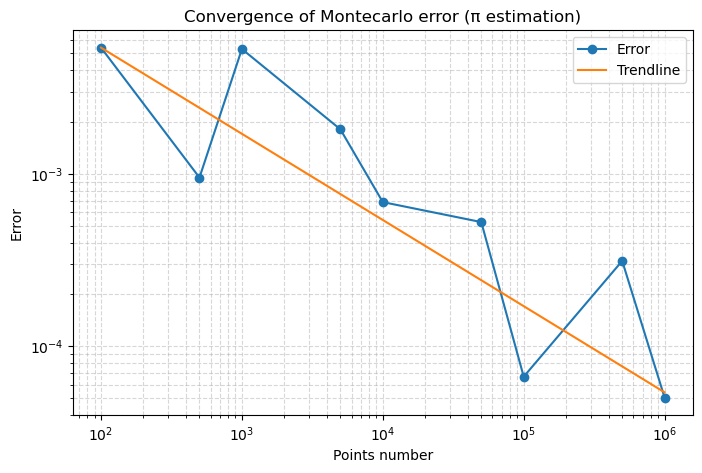

In [1]:
import numpy as np
import matplotlib.pyplot as plt
np.random.seed(42) ### It's optional, depends if you preffer reproducibility or randomly
def estimate_pi(n):
    '''
    Estimate the value of Pi through Montecarlo's method
    Parameters:
    n (int) : number of random points to generate
    Returns an aproximation of number Pi
    '''
    x = np.random.uniform(-1.0 , 1.0 , n)
    y= np.random.uniform(-1.0,1.0,n)
    condition = x**2 + y**2 <= 1
    inside= np.sum(condition)
    pii = inside * 4 / n 
    return pii
values_n = [100, 500, 1000, 5000, 10000, 50000, 100000, 500000,1000000]
n_repetitions= 200
mean_abs_error= []
for i in values_n:
    estimations = [estimate_pi(i) for _ in range(n_repetitions)]
    eabs = abs(np.mean(estimations)- np.pi)
    mean_abs_error.append(eabs)
Trend = (mean_abs_error[0] * np.sqrt(values_n[0])) / np.sqrt(values_n)
plt.figure(figsize=(8,5))
plt.title("Convergence of Montecarlo error (π estimation)")
plt.plot(values_n, mean_abs_error, marker = 'o',label = "Error")
plt.plot(values_n, Trend, label = "Trendline")
plt.legend()
plt.grid(True, which="both", ls="--", alpha=0.5)
plt.xscale('log')
plt.yscale('log')
plt.xlabel("Points number")
plt.ylabel("Error")
plt.show()


## 2. Random Walks

A random walk is the simplest example of a stochastic process evolving over time: at each step, the position changes by a random amount, and the current position is the cumulative sum of all past steps.

$$S_t = S_0 + \sum_{i=1}^{t} \epsilon_i$$

In this section, each step $\epsilon_i$ is either +1 or -1 with equal probability. While simplistic, this discrete random walk introduces two ideas that carry through the rest of the project:

- **Sequential stochastic accumulation**: how a process evolves step by step through random increments, rather than being estimated from a single sample (as in the π example).
- **Simulating multiple paths in parallel**: instead of generating one walk at a time, we generate a matrix of independent walks at once, using vectorized NumPy operations rather than explicit loops. This is the same pattern later used to simulate thousands of asset price paths simultaneously.

This random, cumulative structure is conceptually the discrete ancestor of Brownian motion, which we introduce next.

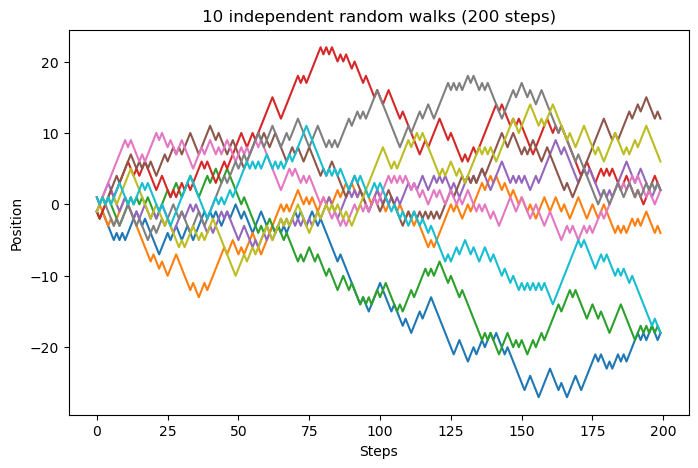

In [2]:
import numpy as np
import matplotlib.pyplot as plt
np.random.seed(42) ### It's optional, depends if you preffer reproducibility or randomly
steps= 200
samples= 10
size = (steps, samples)
random_steps = np.random.choice([-1,1], size=size)
route = np.cumsum(random_steps, axis= 0)
plt.figure(figsize =(8,5))
plt.title(f"{samples} independent random walks ({steps} steps)")
plt.plot(route)
plt.xlabel("Steps")
plt.ylabel("Position")
plt.show()

## 3. Brownian Motion (Wiener Process)

A Wiener process $W_t$ generalizes the discrete random walk into continuous time. It is defined by three properties:

1. $W_0 = 0$
2. Increments are independent of each other.
3. Each increment follows a normal distribution with variance equal to the elapsed time:
$$W_{t+\Delta t} - W_t \sim \mathcal{N}(0, \Delta t)$$

Note that the variance scales with $\Delta t$, not with a fixed value — this ensures the total variance of the process over a fixed horizon stays consistent regardless of how many steps it is divided into. In practice, this means each increment is sampled as `N(0, √dt)`, and the full path is obtained by cumulatively summing these increments.

**Adding a trend (drift):** a pure Brownian motion has no directional tendency — it wanders around zero. To model something like a stock price, which tends to trend over time, we add a **drift** term:

$$\Delta X = \mu \, \Delta t + \sigma \, \Delta W$$

- $\mu$ (drift) is *added*: it determines the average direction of the process over time.
- $\sigma$ (volatility) *multiplies* the random term: it controls how large the random fluctuations are, without affecting direction.

This distinction — a term that shifts the trend vs. a term that scales the noise — is the mathematical backbone of the Geometric Brownian Motion model used for asset prices in the next section.

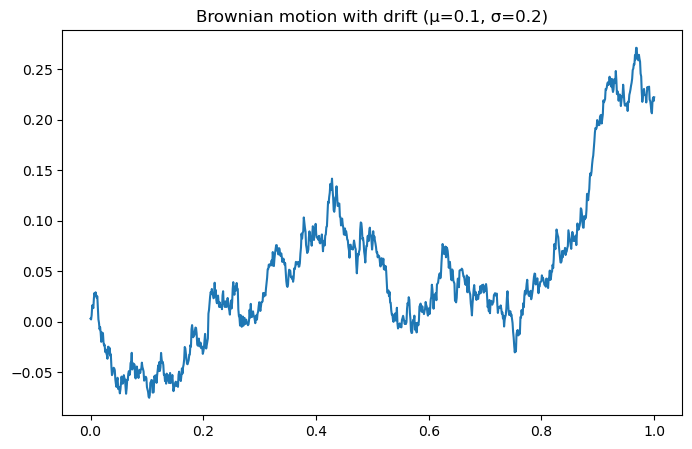

In [3]:
import numpy as np
import matplotlib.pyplot as plt
np.random.seed(42) ### It's optional, depends if you preffer reproducibility or randomly
time= 1
n = 1000
dt = time/n
mu = 0.1
sigma = 0.2
dW = np.random.normal(0, np.sqrt(dt), n)
W = mu*dt + sigma*dW
route= np.cumsum(W) 
time_space = np.linspace(0, time, n)
plt.figure(figsize = (8,5))
plt.title(f"Brownian motion with drift (μ={mu}, σ={sigma})")
plt.plot(time_space, route)
plt.show()

## 4. Geometric Brownian Motion (GBM) and Value at Risk (VaR)

### From Brownian motion to asset prices

The additive model from the previous section has a critical flaw for financial applications: nothing prevents the simulated value from becoming negative, which makes no sense for an asset price.

**The fix:** instead of adding changes directly to the price, GBM assumes that changes are *proportional* to the current price — a 1% move means something different for a €10 stock than for a €1,000 stock. This is expressed through the stochastic differential equation:

$$dS_t = \mu S_t \, dt + \sigma S_t \, dW_t$$

Solving this equation yields a closed-form solution that can be simulated directly:

$$S_t = S_0 \cdot \exp\left[\left(\mu - \frac{\sigma^2}{2}\right)t + \sigma W_t\right]$$

- $S_0$: initial price
- $\mu$, $\sigma$: drift and volatility, as before
- $W_t$: cumulative Brownian motion
- The $-\sigma^2/2$ term is the **Itô correction**, required so that the expected value of the simulated price is consistent with the intended drift $\mu$

Because the result is passed through `exp(...)`, the simulated price is always strictly positive.

### Quantifying risk: Value at Risk (VaR)

With a working GBM engine, we move from simulating price paths to quantifying **risk**.

**Value at Risk (VaR)** answers a concrete question: *"What is the maximum loss that should not be exceeded with a given confidence level (e.g. 95%) over

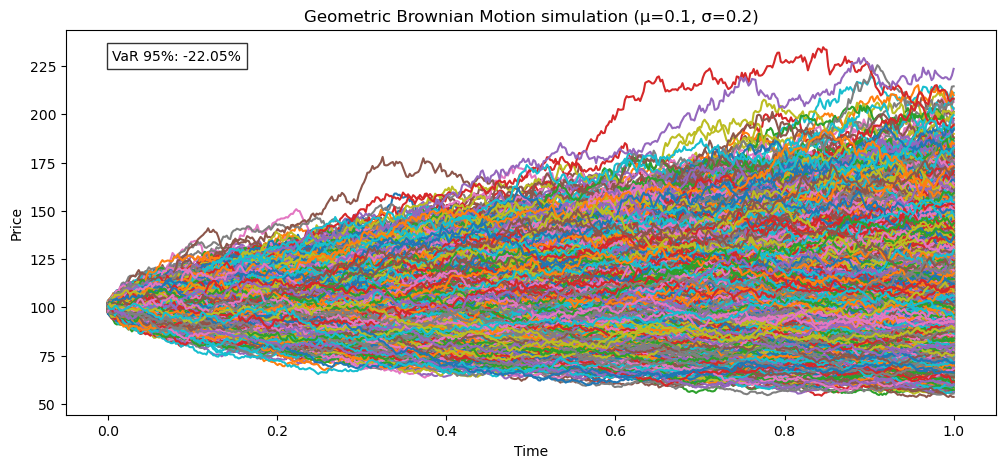

VaR 95%: -22.05%


In [4]:
import numpy as np
import matplotlib.pyplot as plt
np.random.seed(42) ### It's optional, depends if you preffer reproducibility or randomly
S0 = 100
mu = 0.1
sigma= 0.2
time = 1
n = 500
samples = 10000
size = (n, samples)
dt= time/n
dw = np.random.normal(0,np.sqrt(dt), size)
dw_sigma= dw*sigma
brownian_term= np.cumsum(dw_sigma,axis=0)
time_space = np.linspace(0,time,n)
time_space= time_space.reshape(-1,1)
sol= S0 * np.exp((mu-((sigma**2)/2))*time_space + brownian_term)
final = sol[-1,:]
percentage= (final - S0 )/ S0
var_95= np.percentile(percentage,5)
plt.figure(figsize = (12,5))
plt.title(f"Geometric Brownian Motion simulation (μ={mu}, σ={sigma})")
plt.plot(time_space, sol)
plt.text(0.05, 0.95, f"VaR 95%: {(var_95*100).round(2)}%", transform=plt.gca().transAxes, fontsize=10, verticalalignment='top', bbox=dict(facecolor='white', alpha=0.8))
plt.xlabel("Time")
plt.ylabel("Price")
plt.show()
print(f"VaR 95%: {(var_95*100).round(2)}%")

## 5. Correlated Portfolio: Cholesky Decomposition and Diversification

So far, every simulation has assumed a single, independent asset. In reality, a portfolio holds multiple assets whose returns are rarely independent — if the market drops, many stocks tend to fall together.

**Correlation** measures how strongly two assets move together, ranging from -1 (perfectly opposite) to +1 (perfectly synchronized). This has direct implications for risk: diversifying across highly correlated assets provides little protection, since a bad day for one is likely a bad day for the other. Diversifying across weakly or negatively correlated assets can meaningfully reduce risk, since their worst outcomes rarely coincide.

**Generating correlated randomness:** `np.random.normal(...)` generates independent samples by design. To induce a target correlation between two noise series, we use **Cholesky decomposition**: given a correlation matrix, Cholesky produces a matrix $L$ such that, when applied to independent noise $Z$, the result $L \cdot Z$ has the desired correlation structure.

For multiple assets and multiple simulations at once, this multiplication is generalized across all time steps and simulations simultaneously using `np.einsum`, avoiding explicit loops.

**Portfolio-level risk:** with correlated price paths for both assets, the portfolio value at any point is a weighted combination:

$$\text{Portfolio value} = w_1 \cdot S_1 + w_2 \cdot S_2$$

We compute the portfolio's VaR directly from simulated portfolio outcomes, and compare it against the **weighted sum of each asset's individual VaR** (i.e., what the risk would look like if diversification provided no benefit). The difference between these two numbers — the *diversification benefit* — quantifies, in percentage points, how much risk is reduced simply by holding assets that don't move in perfect lockstep.

As shown empirically in this section, this benefit grows substantially as correlation (ρ) decreases, and nearly vanishes as ρ approaches 1 — a direct, simulated confirmation of the "don't put all your eggs in one basket" principle.

In [5]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)  ### It's optional, depends if you prefer reproducibility or randomness

time = 1
n = 500
dt = time / n

S01 = 100
S02 = 100
mu1 = 0.1
mu2 = 0.15
sigma1 = 0.2
sigma2 = 0.25
w1 = 0.6
w2 = 0.4
rho = 0.05  ### correlation

corr_matrix = np.array([[1, rho], [rho, 1]])
chol = np.linalg.cholesky(corr_matrix)

time_space = np.linspace(0, time, n)
time_space = time_space.reshape(-1, 1)

In [6]:
samples = 10000
size = (2, n, samples)

independent_noise = np.random.normal(0, np.sqrt(dt), size)
noise = np.einsum('ij,jkl->ikl', chol, independent_noise)

brownian1 = np.cumsum(noise[0], axis=0)
brownian2 = np.cumsum(noise[1], axis=0)

prices1 = S01 * np.exp((mu1 - (sigma1**2)/2)*time_space + sigma1*brownian1)
prices2 = S02 * np.exp((mu2 - (sigma2**2)/2)*time_space + sigma2*brownian2)

final_price1 = prices1[-1, :]
final_price2 = prices2[-1, :]

portfolio = w1*final_price1 + w2*final_price2
initial_value = S01*w1 + S02*w2
returns = (portfolio - initial_value) / initial_value
var_95 = np.percentile(returns, 5)

returns1 = (final_price1 - S01) / S01
returns2 = (final_price2 - S02) / S02
var_95_1 = np.percentile(returns1, 5)
var_95_2 = np.percentile(returns2, 5)
var_95_weighted = w1*var_95_1 + w2*var_95_2

print(f"Portfolio VaR 95%: {(var_95*100).round(2)}%")
print(f"Asset 1 VaR 95%: {(var_95_1*100).round(2)}% | Asset 2 VaR 95%: {(var_95_2*100).round(2)}%")
print(f"Weighted sum of individual VaRs: {(var_95_weighted*100).round(2)}%")
print(f"Diversification benefit: {((var_95 - var_95_weighted)*100).round(2)} percentage points")

Portfolio VaR 95%: -14.09%
Asset 1 VaR 95%: -22.05% | Asset 2 VaR 95%: -25.05%
Weighted sum of individual VaRs: -23.25%
Diversification benefit: 9.16 percentage points


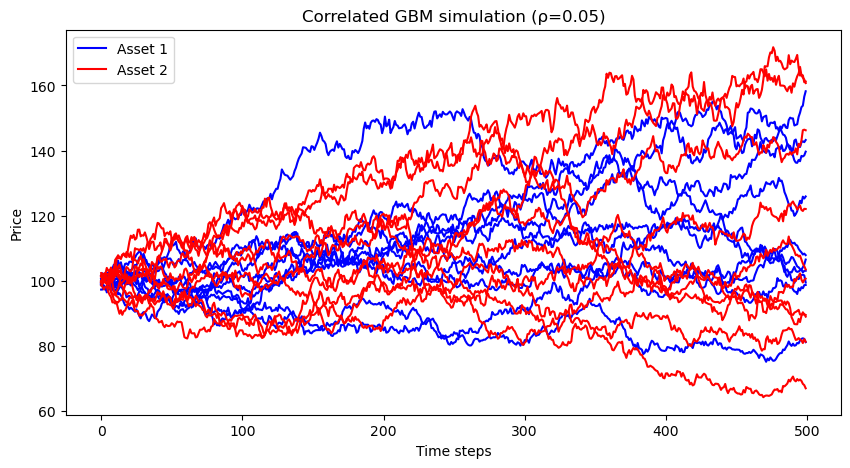

In [7]:
# Note: a smaller sample size is used here purely for visualization clarity.
# The VaR calculation above already used 10,000 simulations for statistical robustness.
samples_plot = 10
size_plot = (2, n, samples_plot)

independent_noise_plot = np.random.normal(0, np.sqrt(dt), size_plot)
noise_plot = np.einsum('ij,jkl->ikl', chol, independent_noise_plot)

brownian1_plot = np.cumsum(noise_plot[0], axis=0)
brownian2_plot = np.cumsum(noise_plot[1], axis=0)

prices1_plot = S01 * np.exp((mu1 - (sigma1**2)/2)*time_space + sigma1*brownian1_plot)
prices2_plot = S02 * np.exp((mu2 - (sigma2**2)/2)*time_space + sigma2*brownian2_plot)

plt.figure(figsize=(10, 5))
plt.plot(prices1_plot[:, 0], color="blue", label="Asset 1")
plt.plot(prices1_plot[:, 1:], color="blue")
plt.plot(prices2_plot[:, 0], color="red", label="Asset 2")
plt.plot(prices2_plot[:, 1:], color="red")
plt.title(f"Correlated GBM simulation (ρ={rho})")
plt.xlabel("Time steps")
plt.ylabel("Price")
plt.legend()
plt.show()

## 6. Option Pricing: Monte Carlo vs. Black-Scholes

This final section applies the GBM engine to price a financial derivative, and validates the simulation against a known closed-form solution.

### What is a European call option?

A European call option gives the holder the **right** (not the obligation) to buy an asset at a fixed price (the **strike**, $K$) on a fixed future date (the **maturity**, $T$). It is only worth exercising if the market price at maturity ($S_T$) is above the strike — otherwise, the holder simply lets it expire worthless.

The payoff at maturity is:

$$\text{Payoff} = \max(S_T - K, 0)$$

### Pricing via Monte Carlo

1. Simulate thousands of GBM price paths. Under **risk-neutral valuation**, the drift $\mu$ is replaced by the risk-free rate $r$ — this is a standard assumption for pricing derivatives, distinct from using a real-world expected return.
2. Compute the payoff for each simulated final price.
3. Average all payoffs — this is the expected payoff at maturity, undiscounted.
4. Discount that average back to present value using $e^{-rT}$, reflecting the time value of money:

$$\text{Option price} = e^{-rT} \cdot \text{mean(payoffs)}$$

### Validation against Black-Scholes

For a plain European call, an exact closed-form solution exists:

$$C = S_0 \cdot N(d_1) - K \cdot e^{-rT} \cdot N(d_2)$$

$$d_1 = \frac{\ln(S_0/K) + (r + \sigma^2/2)T}{\sigma\sqrt{T}}, \quad d_2 = d_1 - \sigma\sqrt{T}$$

where $N(\cdot)$ is the standard normal cumulative distribution function.

Comparing the Monte Carlo price against this analytical result validates the entire simulation pipeline built throughout this project. As shown empirically, increasing the number of simulations (not the number of time steps) reduces the gap between both methods — the same $1/\sqrt{N}$ convergence behavior demonstrated in Section 1 with π, now confirmed in a real derivative pricing

Montecarlo price: 7.9281
Black-Scholes price: 8.0214
Difference: 0.0932


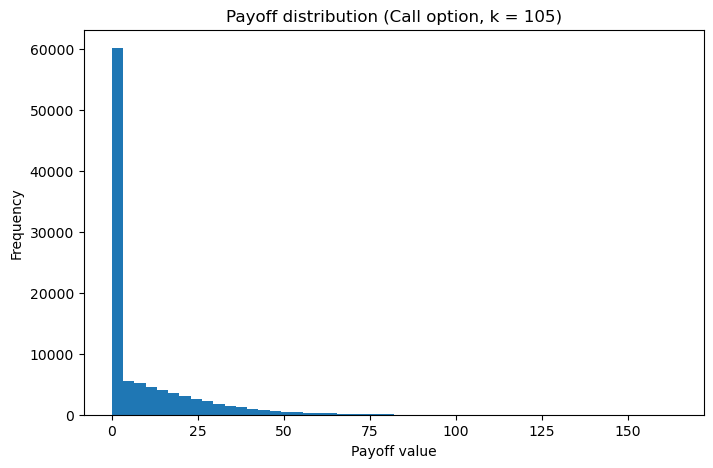

In [8]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm
S0 = 100
k = 105
r= 0.05
sigma= 0.2
time = 1
n = 500
samples = 100000
size = (n, samples)
dt= time/n
dw = np.random.normal(0,np.sqrt(dt), size)
w= dw*sigma
x= np.cumsum(w,axis=0)
time_space = np.linspace(0,time,n)
time_space= time_space.reshape(-1,1)
sol= S0 * np.exp((r-((sigma**2)/2))*time_space + x)
final = sol[-1,:]
payoff = np.maximum(final - k, 0)
option_price= np.exp(-r*time) * np.mean(payoff)
d1 = (np.log(S0 / k) + (r + (sigma**2)/2) *time ) / (sigma * np.sqrt(time))
d2 = d1- sigma*np.sqrt(time)
bs_price = S0*norm.cdf(d1) - k*np.exp(-r*time)*norm.cdf(d2)
plt.figure(figsize= (8,5))
plt.title(f"Payoff distribution (Call option, k = {k})")
plt.ylabel("Frequency")
plt.xlabel("Payoff value")
plt.hist(payoff, bins=50)
print(f"Montecarlo price: {option_price:.4f}")
print(f"Black-Scholes price: {bs_price:.4f}")
print(f"Difference: {abs(option_price - bs_price):.4f}")